In [3]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

caminho = 'data/Consumo_mensal.xlsx'
excel = pd.ExcelFile(caminho)
print("Abas encontradas no arquivo:", excel.sheet_names)

Abas encontradas no arquivo: ['TOTAL', 'RESIDENCIAL', 'INDUSTRIAL', 'COMERCIAL', 'OUTROS', 'CATIVO', 'LIVRE', 'CONSUMIDORES TOTAIS', 'CONSUMIDORES RESIDENCIAIS', 'CONSUMIDORES INDUSTRIAIS', 'CONSUMIDORES COMERCIAIS', 'CONSUMIDORES OUTROS', 'CONSUMIDORES CATIVOS', 'CONSUMIDORES LIVRES', 'INDUSTRIAL GENERO', 'CONSUMO POR UF', 'CONSUMO CATIVO POR UF', 'CONSUMO LIVRE POR UF', 'CONSUMO RESIDENCIAL POR UF', 'CONSUMO INDUSTRIAL POR UF', 'CONSUMO COMERCIAL POR UF', 'CONSUMO OUTROS POR UF', 'CONSUMIDORES RES. POR UF', 'CONSUMIDORES INDUSTRIAIS POR UF', 'CONSUMIDORES COMERCIAIS POR UF', 'CONSUMIDORES OUTROS POR UF', 'CONSUMIDORES CATIVOS POR UF', 'CONSUMIDORES LIVRES POR UF']


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
caminho = 'data/Consumo_mensal.xlsx'
#Lendo a aba especifica de gastos residenciais
df = pd.read_excel(caminho,sheet_name = 'RESIDENCIAL', header=5)

#Ajustando a coluna e filtrando ruídos e títulos
df.rename(columns={df.columns[0]: 'Regiao'}, inplace = True)
df = df.dropna(subset=['Regiao'])
df = df[~df['Regiao'].astype(str).str.contains('REGIÃO|SUBSISTEMA', case = False, na = False)]

#Filtrando as regioes a serem lidas
regioes_validas = ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']
df_limpo = df[df['Regiao'].isin(regioes_validas)].copy()

#Removendo a coluna ANO
df_limpo = df_limpo.dropna(axis=1, how='all')
if 'ANO' in df_limpo.columns:
    df_limpo = df_limpo.drop(columns=['ANO'])
#Transformar a coluna de meses em linhas
m_colunas = [c for c in df_limpo.columns if c != 'Regiao']
df_2 = df_limpo.melt(id_vars = ['Regiao'],
                     value_vars = m_colunas,
                     var_name = 'Mes',
                     value_name = 'Consumo_MWh')
df_2['Consumo_MWh'] = pd.to_numeric(df_2['Consumo_MWh'], errors = 'coerce')

                    



print("Colunas presentes em df_2:", df_2.columns.tolist())
df_2.head(10)

Colunas presentes em df_2: ['Regiao', 'Mes', 'Consumo_MWh']


,Regiao,Mes,Consumo_MWh
0,Norte,JAN,1193981.647
1,Nordeste,JAN,3374101.790
2,Sudeste,JAN,7814175.188
3,Sul,JAN,3083083.306
4,Centro-Oeste,JAN,1524369.851
5,Norte,JAN,1372158.401
6,Nordeste,JAN,2913218.014
7,Sul,JAN,3083083.306
8,Norte,JAN,1114404.424
9,Nordeste,JAN,3236557.183


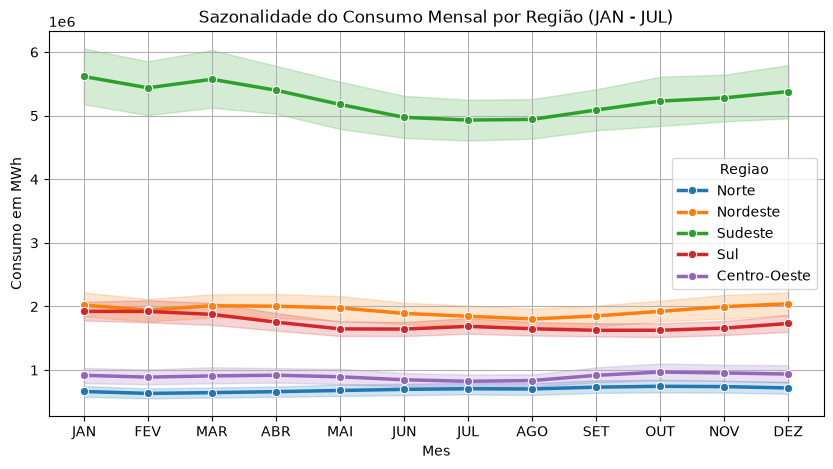

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,5))

sns.lineplot(
    data = df_2,
    x = 'Mes',
    y = 'Consumo_MWh',
    hue = 'Regiao',
    marker = 'o',
    linewidth = 2.5)

plt.title('Sazonalidade do Consumo Mensal por Região (JAN - JUL)')
plt.xlabel('Mes')
plt.ylabel('Consumo em MWh')
plt.grid(True)
plt.show()

In [ ]:
#Aqui quantificaremos a oscilacao de consumo calculando o fator pico/vale
resumo = df_2.groupby('Regiao')['Consumo_MWh'].agg(
    Media = 'mean',
    Desvio_padrao = 'std',
    Minimo = 'min',
    Maximo = 'max',).reset.index()

resumo['Fator Pico/Vale'] = resumo['Maximo'] / resumo['Minimo']
resumo = resumo.sort_values(by = 'Media', ascending = False)
resumo
